# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


## Heart Disease Dataset

**Sumber:** Kaggle — [Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

**Deskripsi:**  
Dataset ini berisi data medis pasien yang digunakan untuk memprediksi apakah seseorang
menderita penyakit jantung. Dataset memiliki 303 baris dan 14 kolom dengan campuran
fitur numerik dan kategorikal.

**Fitur utama:**
- `age` — Usia pasien
- `sex` — Jenis kelamin (1 = laki-laki, 0 = perempuan)
- `cp` — Tipe nyeri dada (0–3)
- `trestbps` — Tekanan darah saat istirahat
- `chol` — Kolesterol serum (mg/dl)
- `thalach` — Detak jantung maksimum
- `target` — Label (1 = ada penyakit jantung, 0 = tidak ada)

**Task:** Binary Classification

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [25]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Utility
import warnings
import os
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 3.0.2
NumPy version: 2.4.4


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [26]:
# Load dataset
# Jika pakai Google Colab, upload file dulu atau mount Drive
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('../heart_raw/heart.csv')  # sesuaikan path jika perlu

# Cek struktur awal
print("=" * 50)
print("SHAPE:", df.shape)
print("=" * 50)
print("\nLIMA BARIS PERTAMA:")
display(df.head())

print("\nINFO DATASET:")
df.info()

print("\nSTATISTIK DESKRIPTIF:")
display(df.describe())

SHAPE: (1025, 14)

LIMA BARIS PERTAMA:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



INFO DATASET:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

STATISTIK DESKRIPTIF:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== MISSING VALUES ===
Empty DataFrame
Columns: [Count, Percentage]
Index: []

Total missing values: 0

=== DUPLIKAT: 723 baris ===


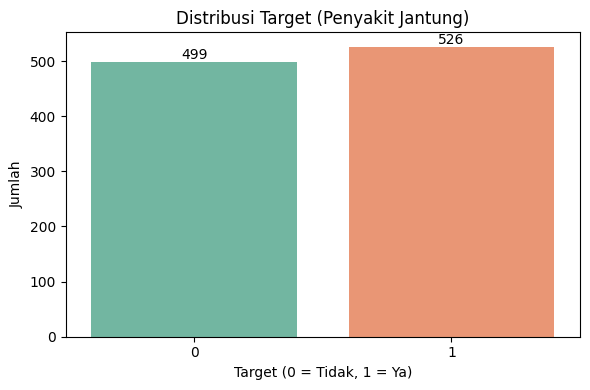

Class balance ratio: {1: 526, 0: 499}


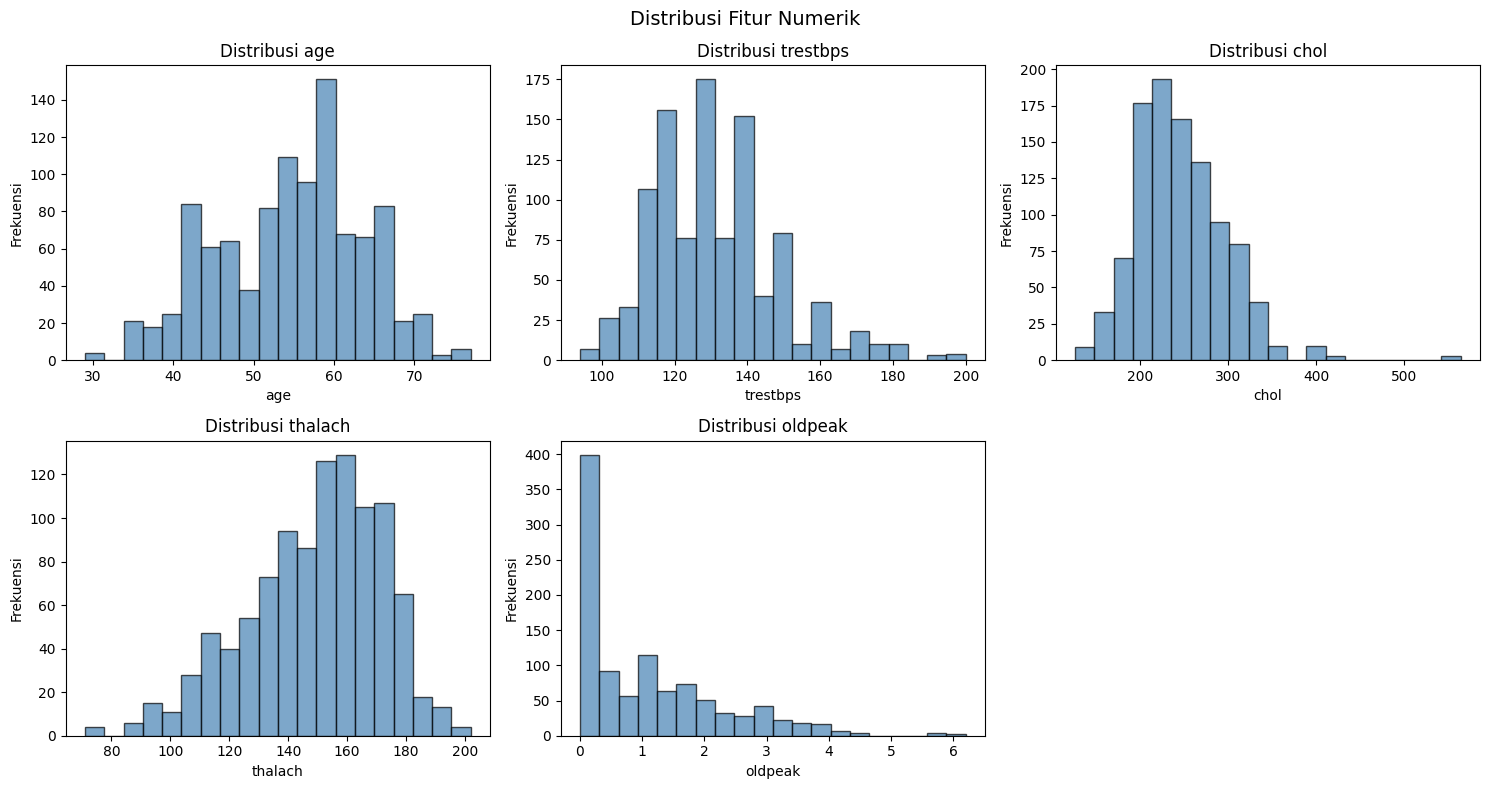

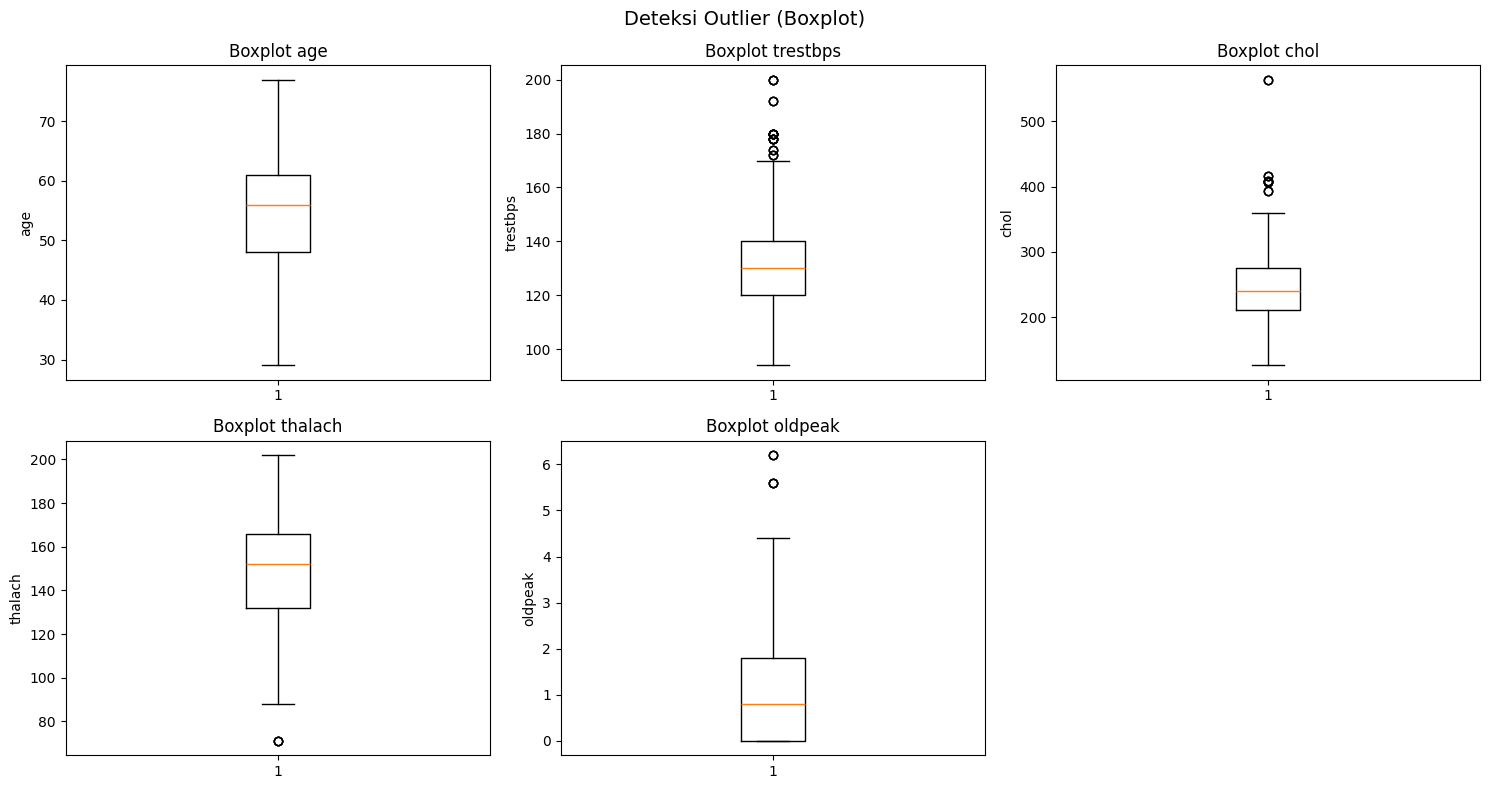

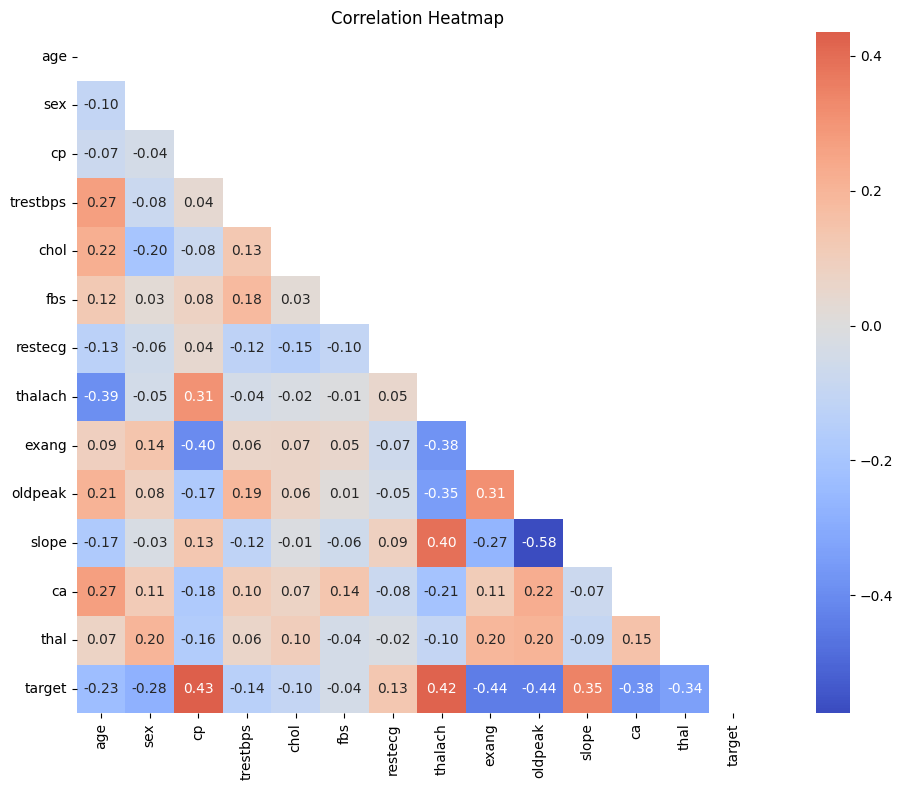

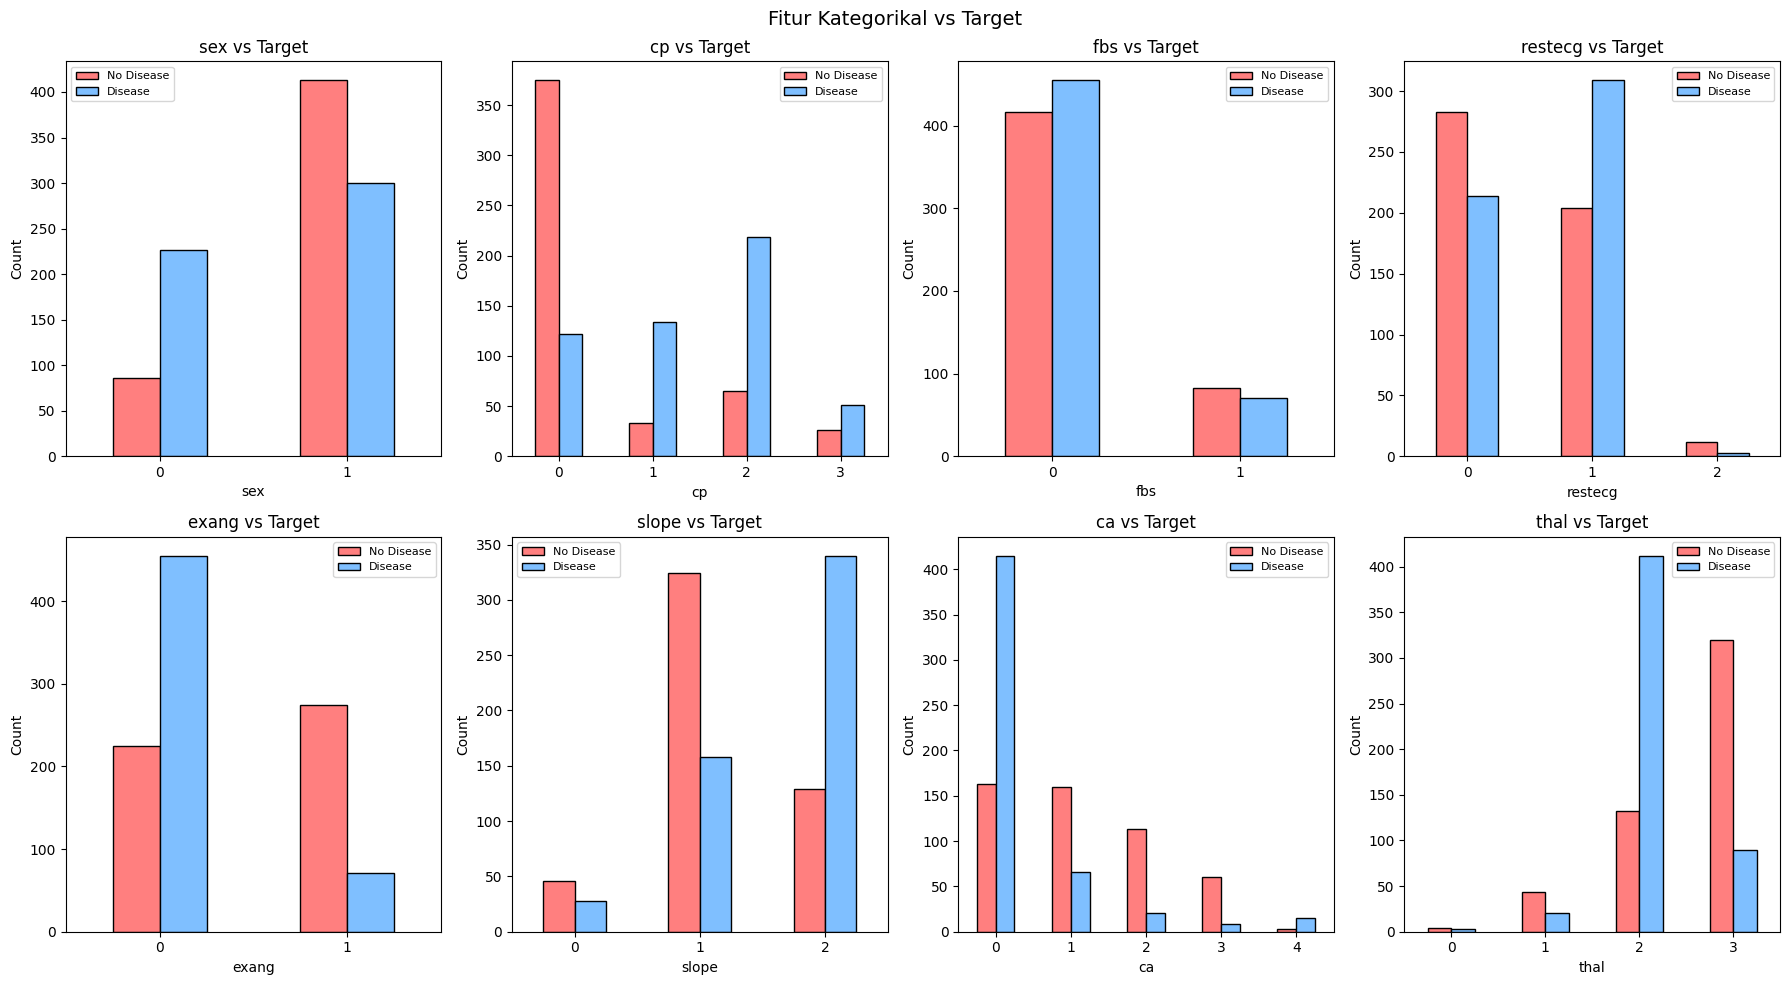


EDA selesai! Semua plot disimpan di folder heart_preprocessing/


In [27]:
# Define your output folder
output_dir = 'heart_preprocessing'

# Create it if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# ── 4.1 Cek Missing Values ──────────────────────────
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Count'] > 0])
print("\nTotal missing values:", df.isnull().sum().sum())

# ── 4.2 Cek Duplikat ────────────────────────────────
print(f"\n=== DUPLIKAT: {df.duplicated().sum()} baris ===")

# ── 4.3 Distribusi Target ───────────────────────────
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribusi Target (Penyakit Jantung)')
plt.xlabel('Target (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('heart_preprocessing/eda_target_distribution.png')
plt.show()
print("Class balance ratio:", df['target'].value_counts().to_dict())

# ── 4.4 Distribusi Fitur Numerik ────────────────────
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.savefig('heart_preprocessing/eda_numerical_distributions.png')
plt.show()

# ── 4.5 Boxplot untuk Outlier ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)
axes[-1].set_visible(False)
plt.suptitle('Deteksi Outlier (Boxplot)', fontsize=14)
plt.tight_layout()
plt.savefig('heart_preprocessing/eda_boxplots.png')
plt.show()

# ── 4.6 Correlation Heatmap ─────────────────────────
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('heart_preprocessing/eda_correlation_heatmap.png')
plt.show()

# ── 4.7 Fitur Kategorikal vs Target ─────────────────
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    crosstab = pd.crosstab(df[col], df['target'])
    crosstab.plot(kind='bar', ax=axes[i], color=['#ff7f7f', '#7fbfff'], edgecolor='black')
    axes[i].set_title(f'{col} vs Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)
plt.suptitle('Fitur Kategorikal vs Target', fontsize=14)
plt.tight_layout()
plt.savefig('heart_preprocessing/eda_categorical_vs_target.png')
plt.show()

print("\nEDA selesai! Semua plot disimpan di folder heart_preprocessing/")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [28]:
# Buat copy agar data asli tidak berubah
df_processed = df.copy()

# ── 5.1 Hapus Duplikat ──────────────────────────────
before = len(df_processed)
df_processed = df_processed.drop_duplicates()
after = len(df_processed)
print(f"Duplikat dihapus: {before - after} baris")
print(f"Shape setelah hapus duplikat: {df_processed.shape}")

# ── 5.2 Handle Missing Values ───────────────────────
# Dataset ini biasanya clean, tapi tetap kita handle
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

num_imputer = SimpleImputer(strategy='median')
df_processed[numerical_cols] = num_imputer.fit_transform(df_processed[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df_processed[categorical_cols] = cat_imputer.fit_transform(df_processed[categorical_cols])

print(f"\nMissing values setelah imputation: {df_processed.isnull().sum().sum()}")

# ── 5.3 Handle Outlier (IQR Method) ─────────────────
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    removed_total = 0
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        removed = before - len(df_clean)
        removed_total += removed
        print(f"  {col}: removed {removed} outliers (range [{lower:.2f}, {upper:.2f}])")
    print(f"Total outlier rows removed: {removed_total}")
    return df_clean

print("\nRemove outliers:")
df_processed = remove_outliers_iqr(df_processed, numerical_cols)
print(f"Shape setelah remove outlier: {df_processed.shape}")

# ── 5.4 Encoding Kategorikal ────────────────────────
# Kolom ini sudah numerik (0/1/2/3) tapi kita pastikan tipenya int
for col in categorical_cols:
    df_processed[col] = df_processed[col].astype(int)

print("\nTipe data setelah encoding:")
print(df_processed.dtypes)

# ── 5.5 Train-Test Split ────────────────────────────
X = df_processed.drop('target', axis=1)
y = df_processed['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test class balance:  {y_test.value_counts().to_dict()}")

# ── 5.6 Normalisasi (StandardScaler) ────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Kembalikan ke DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nContoh data setelah scaling (5 baris pertama):")
display(X_train_scaled.head())

# ── 5.7 Simpan Dataset ──────────────────────────────
train_final = X_train_scaled.copy()
train_final['target'] = y_train.values
test_final = X_test_scaled.copy()
test_final['target'] = y_test.values

train_final.to_csv('heart_preprocessing/heart_train.csv', index=False)
test_final.to_csv('heart_preprocessing/heart_test.csv', index=False)

print("\n✅ Preprocessing selesai!")
print(f"   → heart_preprocessing/heart_train.csv ({train_final.shape})")
print(f"   → heart_preprocessing/heart_test.csv  ({test_final.shape})")

Duplikat dihapus: 723 baris
Shape setelah hapus duplikat: (302, 14)

Missing values setelah imputation: 0

Remove outliers:
  age: removed 0 outliers (range [28.50, 80.50])
  trestbps: removed 9 outliers (range [90.00, 170.00])
  chol: removed 5 outliers (range [116.50, 368.50])
  thalach: removed 1 outliers (range [79.12, 220.12])
  oldpeak: removed 4 outliers (range [-2.40, 4.00])
Total outlier rows removed: 19
Shape setelah remove outlier: (283, 14)

Tipe data setelah encoding:
age         float64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Train size: (226, 13)
Test size:  (57, 13)
Train class balance: {1: 126, 0: 100}
Test class balance:  {1: 32, 0: 25}

Contoh data setelah scaling (5 baris pertama):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.875220,-1.508430,0.026441,-1.623423,-0.866500,-0.39123,0.932715,0.933030,-0.649141,-0.906616,0.959081,-0.722615,-0.419327
1,-1.639769,0.662941,-0.969511,-0.784588,-0.534549,-0.39123,0.932715,-0.422741,-0.649141,0.309379,-0.788922,-0.722615,1.186907
2,0.763099,0.662941,2.018346,0.247825,-0.202598,-0.39123,0.932715,-0.210902,-0.649141,1.728040,-0.788922,1.344612,-0.419327
3,-0.984442,0.662941,0.026441,-0.139330,1.435027,-0.39123,-1.001171,0.848294,-0.649141,-0.906616,0.959081,-0.722615,-0.419327
4,1.746091,0.662941,-0.969511,-0.010278,1.744848,-0.39123,-1.001171,-1.736144,-0.649141,1.525374,-0.788922,2.378226,-0.419327



✅ Preprocessing selesai!
   → heart_preprocessing/heart_train.csv ((226, 14))
   → heart_preprocessing/heart_test.csv  ((57, 14))
